# 1. Write a program to find image segmentation using watershed algorithm

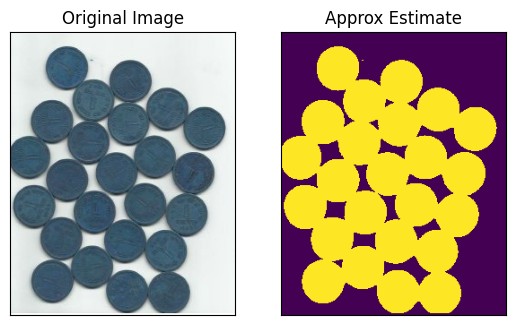

In [1]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
img = cv.imread('/content/coins.png')
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray,0,255,cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
plt.subplot(121),plt.imshow(img)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(thresh)
plt.title('Approx Estimate'),plt.xticks([]),plt.yticks([])
plt.show()

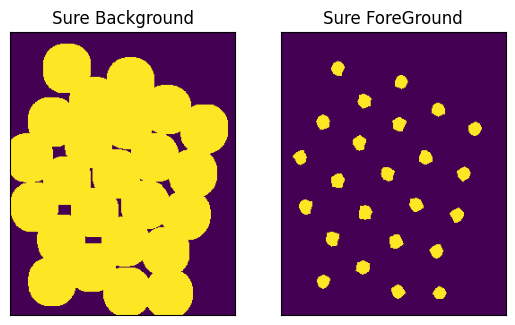

In [3]:
# noise removal
kernel = np.ones((3,3),np.uint8)
opening = cv.morphologyEx(thresh,cv.MORPH_OPEN,kernel,iterations=2)
# sure background area
sure_bg = cv.dilate(opening,kernel,iterations=3)
# Finding sure foreground area
dist_transform = cv.distanceTransform(opening,cv.DIST_L2,5)
ret , sure_fg = cv.threshold(dist_transform,0.7*dist_transform.max(),255,0)
plt.subplot(121),plt.imshow(sure_bg)
plt.title('Sure Background'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(sure_fg)
plt.title('Sure ForeGround'), plt.xticks([]), plt.yticks([])
plt.show()


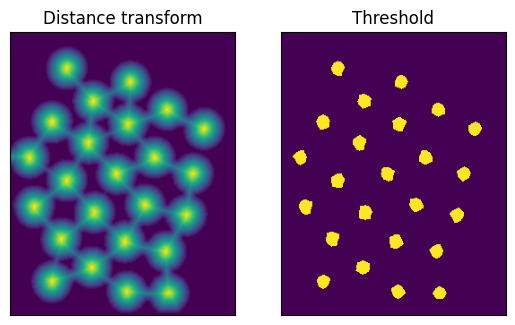

In [4]:
# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg,sure_fg)
plt.subplot(121),plt.imshow(dist_transform)
plt.title('Distance transform'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(sure_fg)
plt.title('Threshold'), plt.xticks([]), plt.yticks([])
plt.show()

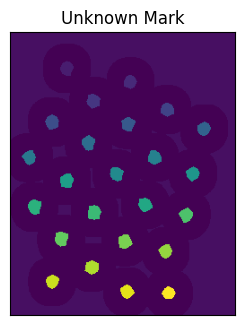

In [5]:
# Marker labelling
ret, markers = cv.connectedComponents(sure_fg)
# Add one to all labels so that sure background is not 0, but 1
markers = markers+1
# Now, mark the region of unknown with zero
markers[unknown==255] = 0

plt.subplot(121),plt.imshow(markers)
plt.title('Unknown Mark'), plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
markers = cv.watershed(img,markers)
img[markers == -1] = [255,0,0]
plt.subplot(121),plt.imshow(markers),plt.title('Markers Image After Segementation')
plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(img),plt.title('Final Result')
plt.xticks([]),plt.yticks([])
plt.show()

# 2. Write a program to find edge (corner detection )of an image

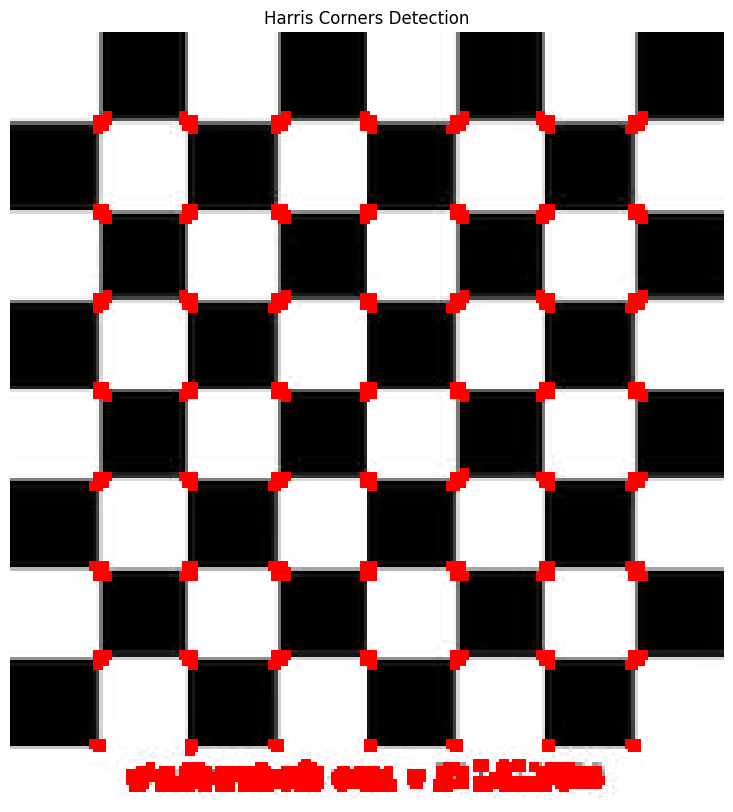

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Load the image
filename = '/content/chessboard.jpg' # Ensure this file is in your Colab environment
img = cv2.imread(filename)
if img is None:
  raise FileNotFoundError(f"Image file '{filename}' not found.")
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Apply Harris Corner Detection
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)
# Dilate result for better visibility
dst = cv2.dilate(dst, None)
# Mark the corners in red
img[dst > 0.01 * dst.max()] = [0, 0, 255]
# Convert BGR to RGB for displaying with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Display the result using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.title('Harris Corners Detection')
plt.axis('off')
plt.show()

# 3. Write a program to find edge of an image using Hough Transform

In [22]:
import cv2
import numpy as np
img = cv2.imread('/content/k1.png')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,150,apertureSize = 3)
lines = cv2.HoughLines(edges,1,np.pi/180,200)
if lines is not None:
  for line in lines:
    a = np.cos(theta)
    rho,theta = line[0]
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(img,(x1,y1),(x2,y2),(0,0,255),2)
cv2.imwrite('output.jpg',img)

True